### Adaptive RAG

In [20]:
import os
import logging
from typing import Literal
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.documents import Document
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

In [2]:
os.environ['ANONYMIZED_TELEMETRY'] = 'False'
logging.getLogger('httpx').setLevel(logging.WARNING)

In [3]:
load_dotenv()

llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)


Load the Store and Build Two Domain-Filtered Retrievers

In [4]:
persist_dir = r'C:\Users\USER\rag_course\chroma_db_domain'

# Load the embedding model
embeddings = OpenAIEmbeddings()

# Open the existing vector store
vectorstore = Chroma(
    persist_directory=persist_dir,
    embedding_function=embeddings
)

# Retriever that only searches crops and health chunks
crops_retriever = vectorstore.as_retriever(
    search_kwargs = {'k': 4, 'filter': {'domain': 'crops'}}
)

health_retriever = vectorstore.as_retriever(
    search_kwargs = {'k': 4, 'filter': {'domain': 'health'}}
)

print(f'Store loaded - {vectorstore._collection.count()} chunks')
print(f'   Crops retriever: filter=domain:crops')
print(f'   Health retriever: filter=domain:health')

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Store loaded - 80 chunks
   Crops retriever: filter=domain:crops
   Health retriever: filter=domain:health


The Domain Classifier

In [5]:
# Prompt that classifies the question into one of three domains
classifier_prompt = ChatPromptTemplate.from_messages([
    ('system',
     'Classify the user question into one of three categories:\n'
     '- CROPS: about crops, plant diseases, treatments, livestock\n'
     '- HEALTH: about human diseases, Nigeria public health\n'
     '- BOTH: question mentions topics from both domains\n'
     '\n'
     'Answer with exactly one word: CROPS, HEALTH, or BOTH.'),
    ('human', '{query}'),
])

# Pipeline: reads the question, returns one word — CROPS, HEALTH, or BOTH
# Chain: prompt -> LLM -> string
classifier_chain = classifier_prompt | llm | StrOutputParser()

Test the Classifier

In [6]:
test_questions = [
    'How do I treat cassava mosaic disease?',
    'What are the top causes of death in Nigeria?',
    'Compare malaria and maize smut',
]

for q in test_questions:
    result = classifier_chain.invoke({'query': q}).strip().lower()
    print(f'{result:<10} <- {q}')

crops      <- How do I treat cassava mosaic disease?
health     <- What are the top causes of death in Nigeria?
both       <- Compare malaria and maize smut


The adaptive_rag() Function

In [7]:
# Main adaptive RAG function — route, retrieve, answer
def adaptive_rag(query: str) -> str:
    
    # Ask the classifier which domain this question belongs to
    domain = classifier_chain.invoke({'query': query}).strip().upper()
    
    print(f'Domain: {domain}')
    
    # Pick the retriever(s) based on the domain
    if 'CROPS' in domain:
        docs = crops_retriever.invoke(query)
    elif 'HEALTH' in domain:
        docs = health_retriever.invoke(query)
    else:
        docs = crops_retriever.invoke(query) + health_retriever.invoke(query)
        
    # Show how many chunks were retrieved
    print(f'Retrieved {len(docs)} chunks')
    
    # Build the context string from the retrieved chunks
    context = '\n\n'.join(d.page_content for d in docs)
    
    # Prompt that answers using only the retrieved context
    answer_prompt = ChatPromptTemplate.from_messages([
        ('system', 'Answer using ONLY the context below. If the answer is not in the context, say "I don\'t know".'),
        ('human', 'Context:\n{context}\nQuery: {query}')
    ])
    
    # Chain: prompt -> LLM -> string
    answer_chain = answer_prompt | llm | StrOutputParser()
    
    # Generate and return the answer
    answer = answer_chain.invoke({
        'context': context,
        'query': query
    })
    
    # Return final answer
    return answer

Test Suite

In [8]:
# Three questions — one per domain
test_questions = [
    'How do I treat cassava mosaic disease?',           
    'What are the top causes of death in Nigeria?',     
    'Compare malaria and maize smut',                    
]

# Run each through the adaptive RAG pipeline
for q in test_questions:
    print(f'\n {q}')
    answer = adaptive_rag(q)
    print(f'{answer}')
    print('-' * 70)


 How do I treat cassava mosaic disease?
Domain: CROPS


Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


Retrieved 4 chunks
To treat cassava mosaic disease, use disease-free cuttings, plant resistant varieties, and remove infected plants early.
----------------------------------------------------------------------

 What are the top causes of death in Nigeria?
Domain: HEALTH
Retrieved 4 chunks
The top causes of death in Nigeria are malaria, lower respiratory infections, HIV/AIDS, diarrheal diseases, road injuries, protein-energy malnutrition, cancer, meningitis, stroke, and tuberculosis.
----------------------------------------------------------------------

 Compare malaria and maize smut
Domain: BOTH
Retrieved 8 chunks
I don't know.
----------------------------------------------------------------------


### Adaptive RAG Using LangGraph

In [9]:
# State that flows through the Adaptive RAG graph
class AdaptiveState(TypedDict, total=False):
    query: str
    domain: str
    docs: List[Document]
    answer: str
    
print('AdaptiveState defined')
print(f'   Fields: {list(AdaptiveState.__annotations__.keys())}')

AdaptiveState defined
   Fields: ['query', 'domain', 'docs', 'answer']


The classify_domain_node

In [10]:
# Node that classifies the query into one of three domains
def classify_domain_node(state: AdaptiveState) -> dict:
    domain = classifier_chain.invoke({
        'query': state['query']
    }).strip().upper()
    print(f'Domain: {domain}')
    
    return {'domain': domain}


# Node: retrieve from crops domain only
def retrieve_crops_node(state: AdaptiveState) -> dict:
    docs = crops_retriever.invoke(state['query'])
    print(f'Retrieved {len(docs)} crops docs')
    
    return {'docs': docs}

# Node: retrieve from health domain only
def retrieve_health_node(state: AdaptiveState) -> dict:
    docs = health_retriever.invoke(state['query'])
    print(f'Retrieved {len(docs)} health docs')
    
    return {'docs': docs}


# Node: retrieve from both domains
def retrieve_both_node(state: AdaptiveState) -> dict:
    docs = crops_retriever.invoke(state['query']) + health_retriever.invoke(state['query'])
    print(f'Retrieved {len(docs)} docs (crops + health)')
    return {'docs': docs}


The Router

In [11]:
# Router: decide which retriever node to run
def route_by_domain(state: AdaptiveState) -> str:
    domain = state['domain']
    
    if 'CROPS' in domain:
        return 'crops'
    
    elif 'HEALTH' in domain:
        return 'health'
    
    else:
        return 'both'

The answer_node

In [12]:
# Node: answer from the retrieved docs
def answer_node(state: AdaptiveState) -> dict:
    
    context = '\n\n'.join(doc.page_content for doc in state['docs'])
    
    prompt = ChatPromptTemplate.from_messages([
        ('system', 'Answer using ONLY the context below. If the answer is not in the context, say "I don\'t know".'),
        ('human', 'Context:\n{context}\n\nQuery: {query}')
    ])
    
    chain = prompt | llm | StrOutputParser()
    
    answer = chain.invoke({
        'context': context,
        'query': state['query']
    })
    
    print('Answered from docs')
    return {'answer': answer}

Build the Graph

In [14]:
# Create the graph
builder = StateGraph(AdaptiveState)

# Register all nodes
builder.add_node('classify_domain', classify_domain_node)
builder.add_node('retrieve_crops', retrieve_crops_node)
builder.add_node('retrieve_health', retrieve_health_node)
builder.add_node('retrieve_both', retrieve_both_node)
builder.add_node('generate_answer', answer_node)

# START → classify
builder.add_edge(START, 'classify_domain')

# classify -> (router) -> one of the three retriever nodes
builder.add_conditional_edges(
    'classify_domain',
    route_by_domain,
    {
        'crops': 'retrieve_crops',
        'health': 'retrieve_health',
        'both': 'retrieve_both'
    }
)

# All retrievers -> answer
builder.add_edge('retrieve_crops', 'generate_answer')
builder.add_edge('retrieve_health', 'generate_answer')
builder.add_edge('retrieve_both', 'generate_answer')

# answer -> END
builder.add_edge('generate_answer', END)

adaptive_app = builder.compile()

print('Adaptive RAG graph compiled')

Adaptive RAG graph compiled


Test the Adaptive RAG Graph

In [19]:
# Run all three test questions through the graph
test_questions = [
    'How do I treat cassava mosaic disease?',           
    'What are the top causes of death in Nigeria?',     
    'Compare malaria and maize smut',                    
]

for q in test_questions:
    print(f'\n❓ {q}')
    result = adaptive_app.invoke({'query': q})
    print(f'{result["answer"]}')
    print('-' * 70)


❓ How do I treat cassava mosaic disease?
Domain: CROPS
Retrieved 4 crops docs
Answered from docs
To treat cassava mosaic disease, use disease-free cuttings, plant resistant varieties, and remove infected plants early.
----------------------------------------------------------------------

❓ What are the top causes of death in Nigeria?
Domain: HEALTH
Retrieved 4 health docs
Answered from docs
The top causes of death in Nigeria are malaria, lower respiratory infections, HIV/AIDS, diarrheal diseases, road injuries, protein-energy malnutrition, cancer, meningitis, stroke, and tuberculosis.
----------------------------------------------------------------------

❓ Compare malaria and maize smut
Domain: BOTH
Retrieved 8 docs (crops + health)
Answered from docs
I don't know.
----------------------------------------------------------------------


Visualize the Graph

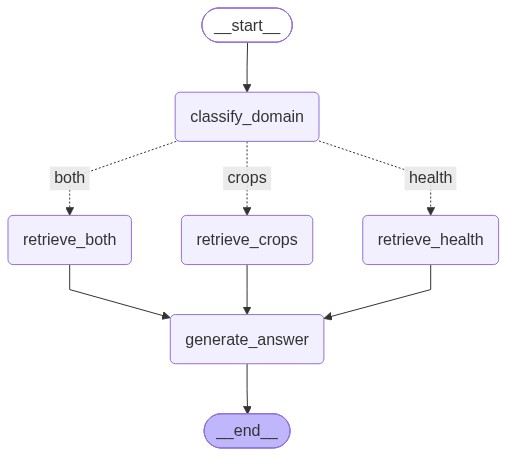

Graph rendered


In [21]:
try:
    display(Image(adaptive_app.get_graph().draw_mermaid_png()))
    print('Graph rendered')
except Exception as e:
    print(f'PNG failed: {e}')
    print('\nASCII fallback:')
    print(adaptive_app.get_graph().draw_ascii())